In [102]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

In [103]:
df=sns.load_dataset('healthexp')
df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    str    
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), str(1)
memory usage: 8.7 KB


In [105]:
df.dtypes

Year                 int64
Country                str
Spending_USD       float64
Life_Expectancy    float64
dtype: object

In [106]:
df.drop_duplicates(inplace=True)

In [107]:
list(df.columns)

['Year', 'Country', 'Spending_USD', 'Life_Expectancy']

## QUESTOIN 1: Analysez la variable "Country".

In [108]:
df['Country'].value_counts()

Country
Japan            51
USA              51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64

<Axes: xlabel='Country'>

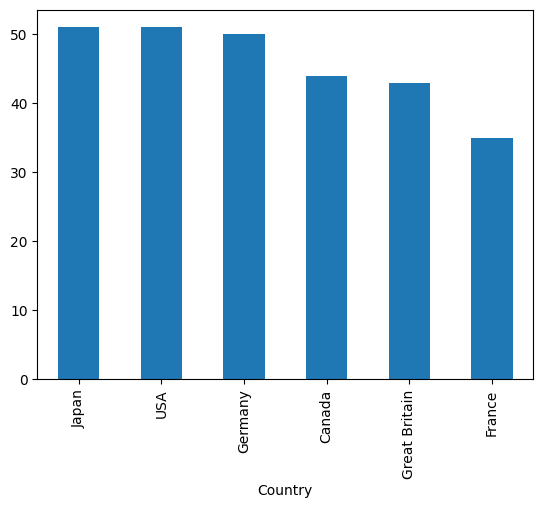

In [109]:
df['Country'].value_counts().plot(kind ="bar")

## Analysez la variable "Spending_USD".

In [110]:
df['Spending_USD'].describe()

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64

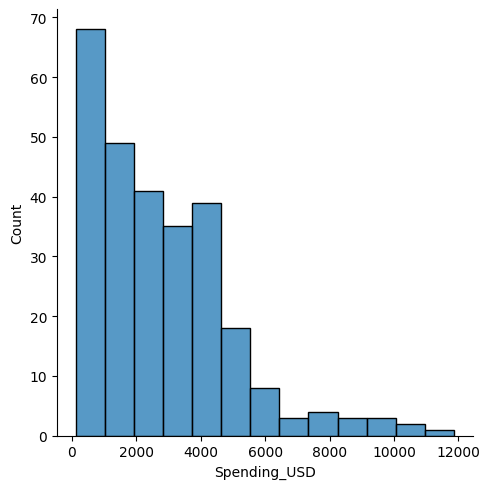

In [111]:
sns.displot(df['Spending_USD'])

<Axes: xlabel='Spending_USD'>

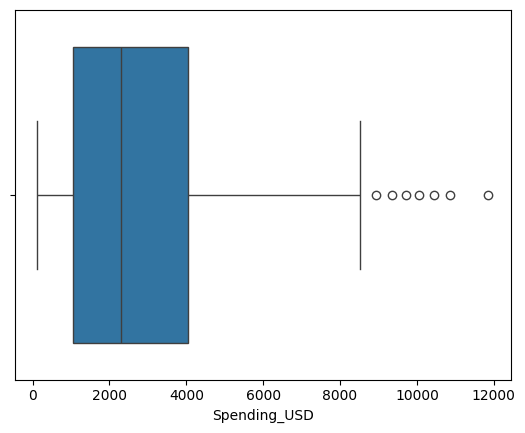

In [112]:
sns.boxplot(data=df, x='Spending_USD')

## Formulez dans une phrase claire ce que signifie la moyenne issue de cette analyse (Attention, soyez vraiment précis, c'est important)
## Réalisez les 2 graphiques utiles pour cette analyse

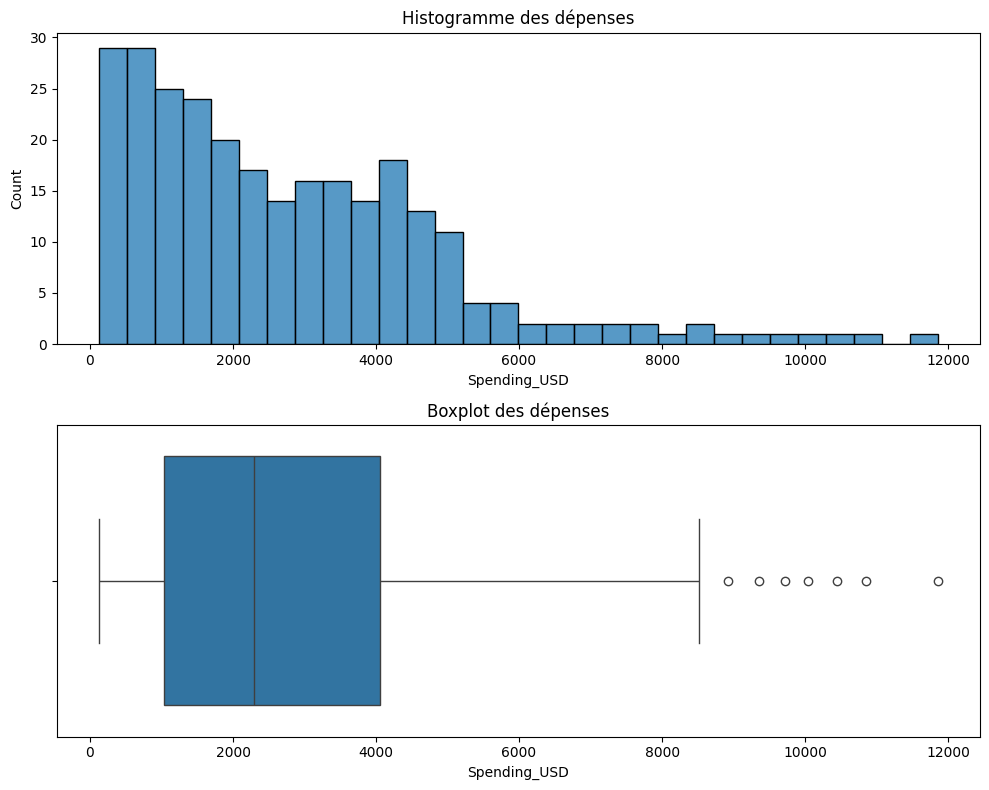

In [113]:
plt.figure(figsize=(10,8))

plt.subplot(2,1,1)
sns.histplot(df["Spending_USD"], bins=30)
plt.title("Histogramme des dépenses")

plt.subplot(2,1,2)
sns.boxplot(x=df["Spending_USD"])
plt.title("Boxplot des dépenses")

plt.tight_layout()
plt.show()

## Faites de même pour la variable "Life_Expectancy"

<Axes: xlabel='Life_Expectancy', ylabel='Count'>

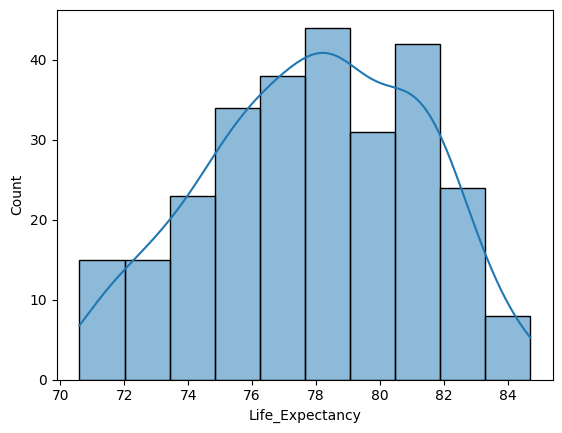

In [114]:
sns.histplot(df['Life_Expectancy'],kde=True)

## Observez l'évolution de la durée de vie à travers le temps.

<Axes: xlabel='Life_Expectancy', ylabel='Year'>

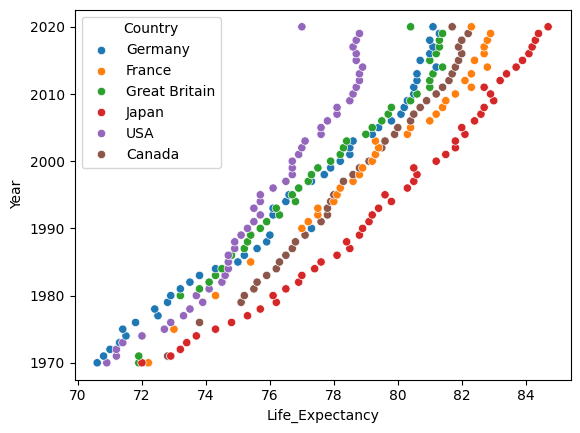

In [115]:
sns.scatterplot(data= df, x='Life_Expectancy', y='Year', hue= 'Country')

## Observez l'évolution des dépenses en santé de l'Allemagne et de la Grande Bretagne à travers le temps.

<Axes: xlabel='Year', ylabel='Spending_USD'>

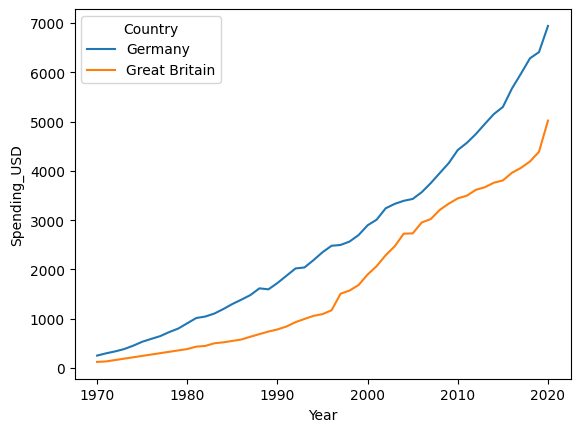

In [116]:
sns.lineplot(data=df[df['Country'].isin(['Germany', 'Great Britain'])], x='Year', y='Spending_USD', hue='Country')

## Observez l'histogramme, la boxplot, et les statistiques de "Life_Expectancy" propre à chaque pays.

<Axes: xlabel='Life_Expectancy', ylabel='Country'>

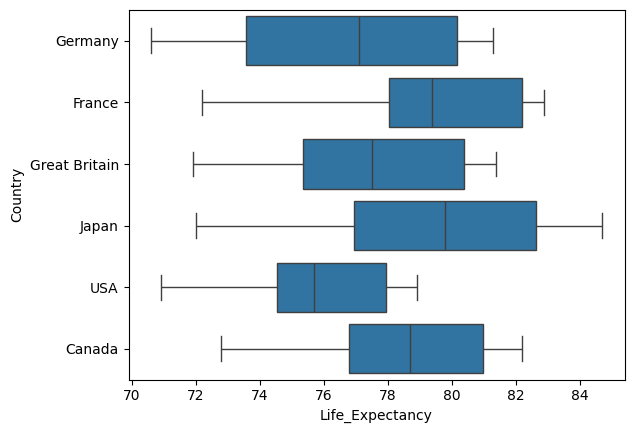

In [117]:
sns.boxplot(data=df,x = 'Life_Expectancy', y = 'Country')

## Observez la relation entre la durée de vie et les dépenses dans la santé, aux États-Unis, de 2000 à 2020

In [118]:
usa = df[(df["Country"] == "USA") & (df["Year"].between(2000, 2020))]

correlation = usa[["Spending_USD", "Life_Expectancy"]].corr()
print(correlation)

                 Spending_USD  Life_Expectancy
Spending_USD         1.000000         0.621067
Life_Expectancy      0.621067         1.000000



## SpendingUSD et LifeExpectancy semblent être corrélées.

Text(0, 0.5, 'Espérance de vie (années)')

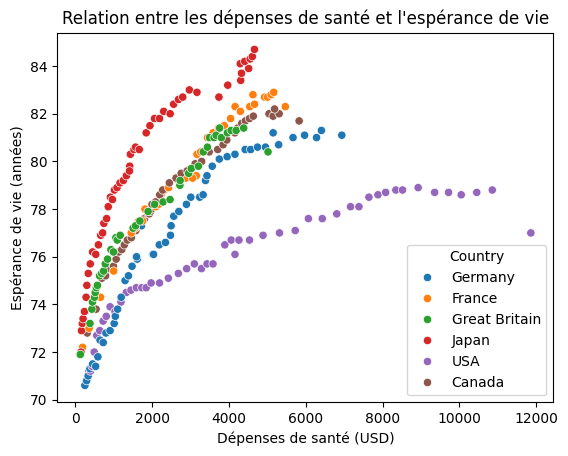

In [119]:
x = df["Spending_USD"]
y = df["Life_Expectancy"]
sns.scatterplot(x=x, y=y, hue=df["Country"])
plt.title("Relation entre les dépenses de santé et l'espérance de vie")
plt.xlabel("Dépenses de santé (USD)")
plt.ylabel("Espérance de vie (années)")

In [126]:
res = pearsonr(df['Spending_USD'], df['Life_Expectancy'])
alpha = 0.05
res
if res[1] < alpha:
    print("relation exist.")
else:
    print("relation does not exist.")

relation exist.
